In [14]:
# Parameter Estimation for a Parametric Curve
# --------------------------------------------
# Model:
#   x = t*cos(θ) - e^(M|t|) * sin(0.3t) * sin(θ) + X
#   y = 42 + t*sin(θ) + e^(M|t|) * sin(0.3t) * cos(θ)
#
# Unknown parameters: θ (degrees), M, X
# Objective: Fit the parameters to observed data (x, y)

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [16]:
# Load the dataset
df = pd.read_csv("xy_data.csv")

# Clean column names (remove spaces, lowercase)
df.columns = df.columns.str.strip().str.lower()

print("Detected columns:", df.columns.tolist())

# Handle possible data formats
if len(df.columns) == 3:
    # Expected format: t, x, y
    t_data = df.iloc[:, 0].to_numpy()
    x_data = df.iloc[:, 1].to_numpy()
    y_data = df.iloc[:, 2].to_numpy()
elif len(df.columns) == 2:
    # If t is missing, generate it uniformly
    print("No t column detected — generating t values automatically.")
    t_data = np.linspace(6, 60, len(df))
    x_data = df.iloc[:, 0].to_numpy()
    y_data = df.iloc[:, 1].to_numpy()
else:
    raise ValueError("The CSV file must have either 2 or 3 numeric columns (t, x, y).")

Detected columns: ['x', 'y']
No t column detected — generating t values automatically.


In [17]:
# Define the parametric model
def model(params, t):
    theta_deg, M, X = params
    theta = np.deg2rad(theta_deg)  # convert degrees to radians
    exp_term = np.exp(M * np.abs(t))
    sin03t = np.sin(0.3 * t)

    x = t * np.cos(theta) - exp_term * sin03t * np.sin(theta) + X
    y = 42 + t * np.sin(theta) + exp_term * sin03t * np.cos(theta)
    return x, y

In [18]:
# Objective function: minimize squared error
def objective(params):
    x_pred, y_pred = model(params, t_data)
    residuals = np.concatenate([x_pred - x_data, y_pred - y_data])
    return np.sum(residuals ** 2)

In [19]:
# Perform optimization using L-BFGS-B method
result = minimize(objective, initial_guess, method='L-BFGS-B', bounds=bounds, options={'ftol': 1e-12})

theta_fit, M_fit, X_fit = result.x
final_error = result.fun

print("\nOptimization Results:")
print(f"Theta (°): {theta_fit:.6f}")
print(f"M:         {M_fit:.8f}")
print(f"X:         {X_fit:.6f}")
print(f"Sum of Squared Errors: {final_error:.6e}")

# Generate fitted values
x_fit, y_fit = model(result.x, t_data)
# Save fitted results to a new CSV file
output_data = pd.DataFrame({
    "t": t_data,
    "x_data": x_data,
    "y_data": y_data,
    "x_fit": x_fit,
    "y_fit": y_fit
})
output_data.to_csv("fitted_results.csv", index=False)
print("\nFitted data has been saved to 'fitted_results.csv'")



Optimization Results:
Theta (°): 29.582824
M:         -0.05000000
X:         55.013614
Sum of Squared Errors: 7.716869e+05

Fitted data has been saved to 'fitted_results.csv'


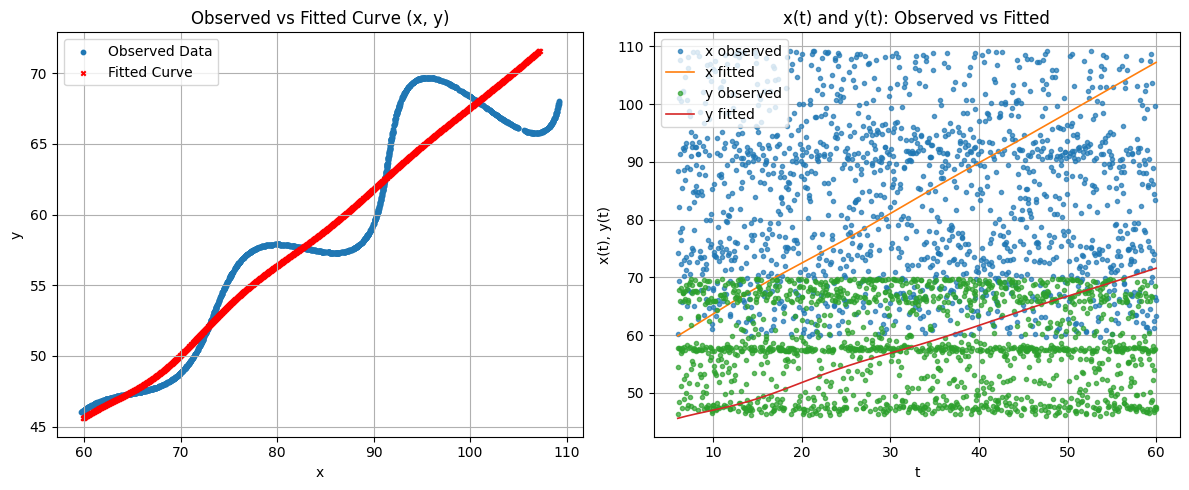


Final Parameter Summary:
            Parameter         Value
            Theta (°)     29.582824
                    M     -0.050000
                    X     55.013614
Sum of Squared Errors 771686.892363


In [20]:


# Visualization
plt.figure(figsize=(12, 5))

# Plot observed vs fitted data in xy-plane
plt.subplot(1, 2, 1)
plt.scatter(x_data, y_data, label='Observed Data', s=10)
plt.scatter(x_fit, y_fit, label='Fitted Curve', s=10, marker='x', color='red')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Observed vs Fitted Curve (x, y)')
plt.legend()
plt.grid(True)

# Plot x(t) and y(t)
plt.subplot(1, 2, 2)
plt.plot(t_data, x_data, '.', label='x observed', alpha=0.7)
plt.plot(t_data, x_fit, '-', label='x fitted', linewidth=1.2)
plt.plot(t_data, y_data, '.', label='y observed', alpha=0.7)
plt.plot(t_data, y_fit, '-', label='y fitted', linewidth=1.2)
plt.xlabel('t')
plt.ylabel('x(t), y(t)')
plt.title('x(t) and y(t): Observed vs Fitted')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Print final parameter summary
summary = pd.DataFrame({
    "Parameter": ["Theta (°)", "M", "X", "Sum of Squared Errors"],
    "Value": [theta_fit, M_fit, X_fit, final_error]
})

print("\nFinal Parameter Summary:")
print(summary.to_string(index=False))
